<a href="https://colab.research.google.com/github/Eng-NadeenShadeed/BinX_AI_ML_Internship/blob/main/Week7/Day%204/day4_attention_transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 4', exist_ok=True)
os.chdir('/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 4')
print("Ready ✓")

Mounted at /content/drive
Ready ✓


# Week 7 · Day 4 — Attention & Transformers
**BinX Tech — AI & ML Internship**

Self-Attention, Transformer Architecture & Hugging Face — Medical Abstracts Classification

## 1. Connection to Day 3

| Day | Architecture | Key Idea | Limitation |
|-----|-------------|----------|------------|
| Day 3 | Plain RNN | Hidden state carries memory | Vanishing gradient — forgets early steps |
| Day 3 | LSTM | Gates protect gradient flow | Still sequential — slow, memory bottleneck |
| Day 4 | Transformer | Attention — direct access to all positions | Needs positional encoding — no inherent order |

LSTM solved the vanishing gradient problem but kept two fundamental constraints:
sequential processing (no parallelism) and a fixed-size memory bottleneck.
Transformers remove both — by replacing recurrence with attention entirely.

---

## 2. Limitations of RNNs & LSTMs

**Sequential Processing:**
An RNN reads token 1, then token 2, then token 3 — each step depends on the
previous one. This means step 100 cannot be computed until steps 1-99 are done.
Training on long sequences is slow because nothing can be parallelized.

**Memory Bottleneck:**
After processing a sequence of 500 tokens, the entire context is compressed
into one hidden state vector (e.g. 64 or 128 numbers). No matter how long
the sequence, the final vector has the same size. Information from early tokens
gets diluted or lost.

**Long-Range Dependencies:**
Even with LSTM, the gradient path from token 500 back to token 1 passes through
500 operations. The cell state helps, but very distant dependencies are still
harder to learn than nearby ones.

| Limitation | RNN | LSTM | Transformer |
|-----------|-----|------|-------------|
| Vanishing gradient | ✗ Severe | ✓ Solved | ✓ No recurrence |
| Parallelism | ✗ None | ✗ None | ✓ Full |
| Memory bottleneck | ✗ Fixed vector | ✗ Fixed vector | ✓ All tokens accessible |
| Long-range dependencies | ✗ Poor | ~ Partial | ✓ Direct access |

---

## 3. The Idea of Attention

In a long sentence, not every word is equally relevant to understanding every
other word. When reading "The cat sat on the mat because it was tired", to
understand what "it" refers to, you look back at "cat" — not at "mat" or "on".

RNNs cannot do this directly — they pass information step by step and hope
it survives to the relevant position. Attention gives every token direct,
weighted access to every other token in the sequence.

**Intuitive example:**
Sentence: "The surgery was successful but the patient is still recovering."

To classify this sentence, the model needs to focus on "successful" AND
"still recovering" — two pieces of information far apart in the sentence.
Attention lets the model look directly at both, regardless of distance.

**What attention produces:**
For each token, a weighted sum of all other tokens — where the weights
reflect how relevant each token is to the current one. The result is a
context-aware representation of each token that incorporates information
from the entire sequence simultaneously.

---

## 4. Attention Mechanism

For each token, attention computes:
1. **Attention scores** — how relevant is every other token to this one?
2. **Softmax** — convert scores to probabilities (sum to 1)
3. **Weighted sum** — combine all token representations, weighted by relevance

The result: each token gets a new representation that is a weighted blend
of all other tokens — with more weight on the relevant ones.

This replaces the step-by-step hidden state update of an RNN with a single
matrix operation that processes all tokens simultaneously.

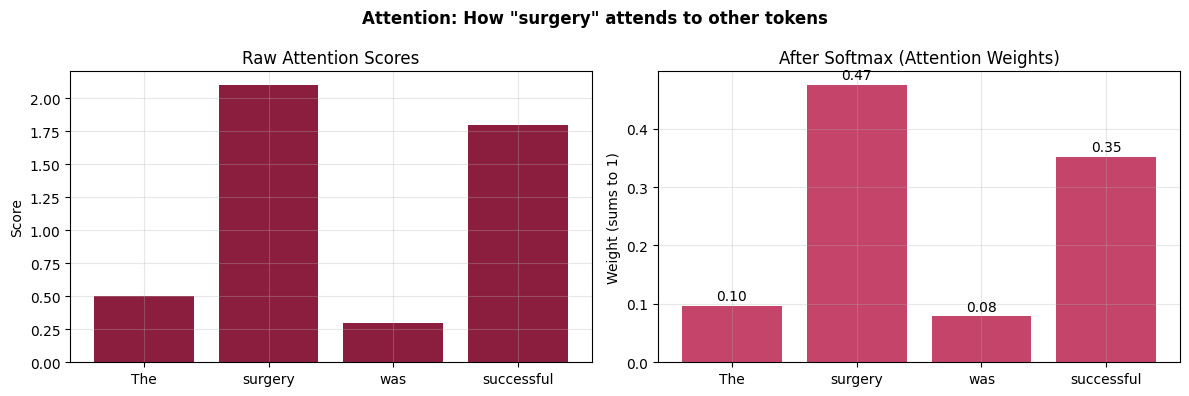

Attention weights sum to: 1.0

Token weights:
  The         : 0.0958
  surgery     : 0.4744
  was         : 0.0784
  successful  : 0.3514


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Simple attention demo — 4 tokens
tokens = ["The", "surgery", "was", "successful"]

# Simulated attention scores (what "surgery" attends to)
scores = np.array([0.5, 2.1, 0.3, 1.8])
weights = np.exp(scores) / np.exp(scores).sum()  # softmax

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Attention: How "surgery" attends to other tokens',
             fontsize=12, fontweight="bold")

axes[0].bar(tokens, scores, color="#8B1E3F")
axes[0].set_title("Raw Attention Scores")
axes[0].set_ylabel("Score")
axes[0].grid(True, alpha=0.3)

axes[1].bar(tokens, weights, color="#C44569")
axes[1].set_title("After Softmax (Attention Weights)")
axes[1].set_ylabel("Weight (sums to 1)")
for i, w in enumerate(weights):
    axes[1].text(i, w + 0.01, f"{w:.2f}", ha="center", fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Attention weights sum to:", weights.sum().round(4))
print("\nToken weights:")
for t, w in zip(tokens, weights):
    print(f"  {t:<12}: {w:.4f}")

### What the Plot Shows

The raw scores are arbitrary numbers — the model computes these based on
learned weights. Softmax converts them to probabilities that sum to 1.

"surgery" (score 2.1) gets the highest attention weight — the model learned
it is the most relevant token in this context. "successful" (score 1.8)
gets the second highest. "The" and "was" get low weights — they carry
little semantic meaning for this token.

In a real Transformer, these scores are not manually set — they are learned
from data through the Query, Key, and Value matrices explained next.

---

## 5. Self-Attention — Q, K, V

Self-attention computes attention of each token over all other tokens
in the same sequence. It uses three learned matrices to transform each token:

| Matrix | Name | Role |
|--------|------|------|
| **Q** | Query | "What am I looking for?" |
| **K** | Key | "What do I contain?" |
| **V** | Value | "What do I contribute?" |

For each token, the Query is compared against every Key using a dot product.
The result is the attention score. After softmax, these scores weight the Values
to produce the final output for each token.

```
Q = X × W_Q (transform input to queries)
K = X × W_K (transform input to keys)
V = X × W_V (transform input to values)

Attention(Q, K, V) = softmax(Q × Kᵀ / √d_k) × V

```

The √d_k scaling prevents dot products from growing too large when
the dimension d_k is high — large dot products push softmax into regions
where gradients are very small.

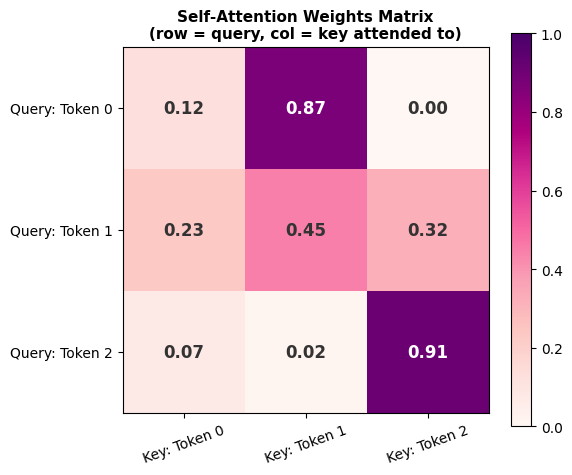

Input shape : (3, 4) → (seq_len, d_k)
Q, K, V shape: (3, 4)
Attention weights shape: (3, 3)
Output shape: (3, 4)

Each row sums to 1.0 (softmax):
[1. 1. 1.]


In [3]:
import numpy as np

np.random.seed(42)

# Simplified self-attention — 3 tokens, dimension 4
seq_len = 3
d_k = 4

# Simulated input embeddings (3 tokens × 4 dimensions)
X = np.random.randn(seq_len, d_k)

# Learned weight matrices (normally trained — here random for demo)
W_Q = np.random.randn(d_k, d_k)
W_K = np.random.randn(d_k, d_k)
W_V = np.random.randn(d_k, d_k)

# Compute Q, K, V
Q = X @ W_Q
K = X @ W_K
V = X @ W_V

# Attention scores
scores = Q @ K.T / np.sqrt(d_k)

# Softmax
def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

weights = softmax(scores)

# Weighted sum of values
output = weights @ V

# Visualize attention weights
fig, ax = plt.subplots(figsize=(6, 5))
tokens = ["Token 0", "Token 1", "Token 2"]
im = ax.imshow(weights, cmap="RdPu", vmin=0, vmax=1)
ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
ax.set_xticklabels([f"Key: {t}" for t in tokens], rotation=20)
ax.set_yticklabels([f"Query: {t}" for t in tokens])
ax.set_title("Self-Attention Weights Matrix\n(row = query, col = key attended to)",
             fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax)
for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, f"{weights[i,j]:.2f}", ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="white" if weights[i,j] > 0.5 else "#333")
plt.tight_layout()
plt.show()

print("Input shape :", X.shape, "→ (seq_len, d_k)")
print("Q, K, V shape:", Q.shape)
print("Attention weights shape:", weights.shape)
print("Output shape:", output.shape)
print("\nEach row sums to 1.0 (softmax):")
print(weights.sum(axis=1).round(4))

### Interpreting the Attention Heatmap

The heatmap shows the **Self-Attention Weights Matrix**, where each row represents a **Query** and each column represents the **Key** that it attends to.

* **Token 0** attends mostly to **Token 1**, with an attention weight of **0.87**. This means Token 1 receives the highest attention from Token 0.
* **Token 1** distributes its attention across all three tokens, with the highest weight on **itself (0.45)**.
* **Token 2** attends mostly to **itself**, with a weight of **0.91**, while giving very little attention to Token 0 and Token 1.
* Each row sums to **1.0**, because the attention scores are converted into normalized weights using **Softmax**.

The `3 × 3` matrix occurs because each of the **3 Query tokens compares itself with all 3 Key tokens**.

> **Note:** The attention scores in this demonstration are based on randomly generated inputs and randomly initialized weight matrices. Therefore, the heatmap is an **educational illustration of the Self-Attention mechanism**, not a representation of learned attention from a real language model.


---

## 6. Multi-Head Attention

Instead of computing attention once with the full dimension, Transformers
run attention h times in parallel — each with smaller dimension d_k / h.
Each "head" learns to attend to different types of relationships:

- Head 1 might learn syntactic relationships (subject-verb)
- Head 2 might learn semantic relationships (word meaning)
- Head 3 might learn positional relationships (nearby words)

The outputs of all heads are concatenated and projected back to the
original dimension.


```
MultiHead(Q,K,V) = Concat(head_1, ..., head_h) × W_O
where head_i = Attention(Q×W_Qi, K×W_Ki, V×W_Vi)
```


**Why multiple heads?**
A single attention computation captures one type of relationship per query-key pair.
Multiple heads capture multiple relationship types simultaneously — giving the model
a richer representation of the sequence.

---

## 7. Why Transformers Can Be Parallelized

**RNN dependency chain:**


```
h1 = f(x1)
h2 = f(x2, h1) ← must wait for h1
h3 = f(x3, h2) ← must wait for h2
...
hN = f(xN, hN-1) ← must wait for all previous
```
Each step depends on the previous — the entire sequence must be processed serially.

**Self-attention:**


```
Q = X × W_Q
K = X × W_K
V = X × W_V
Output = softmax(Q × Kᵀ / √d_k) × V
```
These are matrix multiplications — all tokens are processed simultaneously
in a single operation. GPUs are designed exactly for this kind of parallel computation.

**Important note:**
Parallelism applies during **training**. Autoregressive generation (GPT-style)
is still sequential at inference — the model generates one token at a time,
because each token depends on all previous generated tokens.



---

## 8. Long-Range Dependencies

**RNN/LSTM path from token 1 to token 500:**
Information from token 1 must travel through 499 recurrent steps.
Even with LSTM's protected cell state, 499 multiplicative operations
introduce some degradation — and the gradient path during training is equally long.

**Transformer direct connection:**
Every token attends directly to every other token — distance does not matter.
Token 1 and token 500 have the same direct connection as token 499 and token 500.

For medical abstracts — which can be hundreds of words long — this matters:
a word at the beginning of an abstract (e.g. the disease name) is directly
accessible to a word at the end (e.g. the outcome), with no information loss.

---

## 9. Transformer Architecture

A Transformer encoder stacks the following components:


```
Input text
↓
Tokenization — split text into tokens
↓
Token Embeddings — map each token to a dense vector
↓
Positional Encoding — add position information
↓
[Repeated N times:]
Multi-Head Self-Attention
Add & Norm (residual connection + layer normalization)
Feed-Forward Network
Add & Norm
↓
Final representation → classification head
```


**Residual connections:** add the input of each sub-layer to its output.
This prevents gradient vanishing in deep networks — a direct path for gradients
to flow through many layers unchanged.

**Layer normalization:** stabilizes training by normalizing activations
within each layer — standard practice in Transformer training.

---

## 10. Transformer Encoder vs Decoder

Transformers can be built using **Encoder layers, Decoder layers, or both**, depending on the task.

### Encoder

The Encoder reads the input sequence and builds contextual representations.

```text
Input → Encoder → Contextual Representation
```

The Encoder uses self-attention to allow each token to attend to other tokens in the input.

**Example:** BERT is an **Encoder-only** Transformer and is mainly used for understanding tasks such as text classification, named entity recognition, and question answering.

### Decoder

The Decoder is designed to generate an output sequence.

In autoregressive generation, each new token can attend only to previous tokens, preventing it from using future tokens.

```text
Previous Tokens → Decoder → Next Token
```

**Example:** GPT-2 is a **Decoder-only** Transformer designed primarily for text generation.

### Encoder–Decoder

Some Transformer models use both components:

```text
Input
  ↓
Encoder
  ↓
Contextual Representation
  ↓
Decoder
  ↓
Output
```

This architecture is useful for tasks where the model needs to understand an input and generate another sequence, such as translation and summarization.

### Key Difference

**Encoder → Understand the input**

**Decoder → Generate the output**

**Encoder–Decoder → Understand an input and generate an output**


---

## 11. Positional Encoding

Self-attention has no inherent sense of order — the attention matrix treats
tokens as a set, not a sequence. Shuffling the tokens would produce different
attention weights but the model would have no way to know the order changed.

**Solution: Positional Encoding**
Add a position-dependent vector to each token embedding before the first
attention layer. The model then has access to both the token's meaning
and its position in the sequence.

**Sinusoidal encoding (original Transformer):**
```
PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
```

Different frequencies encode different scales of position — short-range
and long-range structure are both captured. The sinusoidal pattern also
generalizes to sequence lengths not seen during training.

**Modern methods:** learned positional embeddings (BERT), relative position
encodings (T5), rotary embeddings (LLaMA) — all solve the same fundamental
problem of giving the Transformer a sense of order.

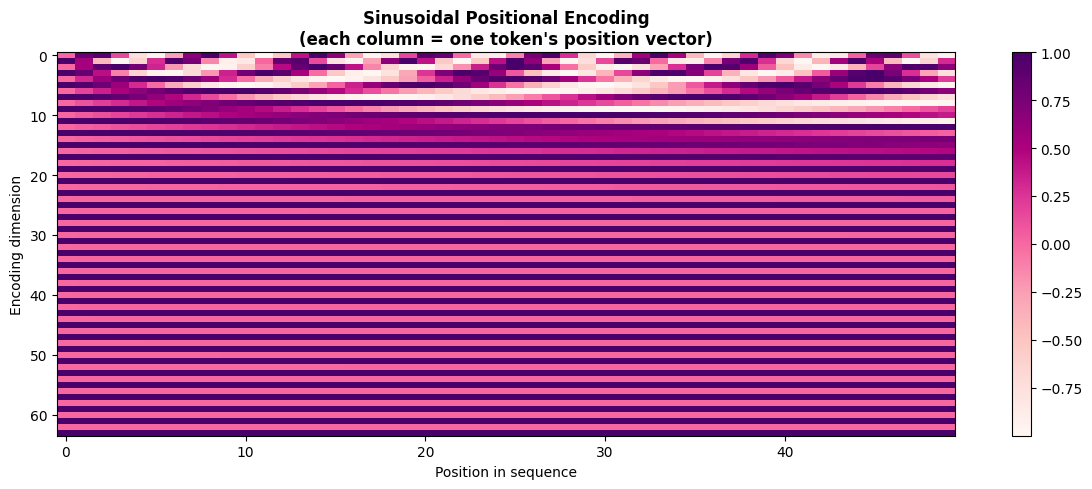

Positional encoding shape: (50, 64)
(50 positions × 64 dimensions)

Each token gets a unique position vector added to its embedding.
The sinusoidal pattern allows the model to generalize to
sequence lengths not seen during training.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(max_len, d_model):
    PE = np.zeros((max_len, d_model))
    for pos in range(max_len):
        for i in range(0, d_model, 2):
            PE[pos, i]   = np.sin(pos / 10000 ** (2*i / d_model))
            if i+1 < d_model:
                PE[pos, i+1] = np.cos(pos / 10000 ** (2*i / d_model))
    return PE

PE = positional_encoding(max_len=50, d_model=64)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(PE.T, cmap="RdPu", aspect="auto")
ax.set_xlabel("Position in sequence")
ax.set_ylabel("Encoding dimension")
ax.set_title("Sinusoidal Positional Encoding\n(each column = one token's position vector)",
             fontsize=12, fontweight="bold")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("Positional encoding shape:", PE.shape)
print("(50 positions × 64 dimensions)")
print("\nEach token gets a unique position vector added to its embedding.")
print("The sinusoidal pattern allows the model to generalize to")
print("sequence lengths not seen during training.")

### Interpreting the Positional Encoding Heatmap

The heatmap visualizes the **Sinusoidal Positional Encoding**, where each column represents the positional vector assigned to a token position.

* **X-axis — Position in Sequence:** Represents the position of each token in the sequence, from `0` to `49`.
* **Y-axis — Encoding Dimension:** Represents the dimensions of the positional encoding vector, from `0` to `63`.
* **Color:** Represents the value of the positional encoding at each position and dimension, ranging from approximately `-1` to `1`.

### Key Observations

* **Higher-frequency dimensions:** The upper dimensions change more rapidly across positions, capturing fine-grained positional differences between nearby tokens.
* **Lower-frequency dimensions:** The lower dimensions change more slowly, capturing broader positional patterns across the sequence.
* **Alternating patterns:** The sinusoidal and cosine functions create repeating patterns across the dimensions and positions.
* **Unique position patterns:** Each position receives a distinct combination of values across the dimensions, allowing the model to distinguish between different positions.

**Key Insight:**
Positional Encoding provides the Transformer with information about **where each token appears in the sequence**, complementing the information provided by the Token Embeddings.

> **Note:** The positional encoding values are deterministic and are generated directly from the sinusoidal functions; they are not learned during training in the original Transformer.


---

## 12. Transformer Families

| Family | Examples | How it works | Best for |
|--------|---------|--------------|----------|
| **Encoder** | BERT, DistilBERT, RoBERTa | Bidirectional — sees full context | Classification, NER, QA |
| **Decoder** | GPT-2, GPT-4, LLaMA | Left-to-right — autoregressive | Text generation |
| **Encoder-Decoder** | T5, BART, mT5 | Encoder processes input, decoder generates output | Translation, summarization |

**BERT** (Bidirectional Encoder Representations from Transformers):
Pretrained on masked language modeling and next sentence prediction.
Sees context from both directions — left and right — simultaneously.

**DistilBERT:**
A distilled (compressed) version of BERT — 40% fewer parameters, 60% faster,
retains 97% of BERT's performance. Ideal for tasks with limited compute.

**GPT-2:**
Decoder-only — generates text left to right. Not suitable for classification
without fine-tuning — designed for text generation tasks.

---

## 13. Pre-trained Transformers & Transfer Learning

The connection to Day 2 (Transfer Learning) is direct:

| Day 2 — CNN | Day 4 — Transformer |
|-------------|---------------------|
| MobileNetV2 pretrained on ImageNet | DistilBERT pretrained on Wikipedia + BookCorpus |
| Frozen base + new classification head | Frozen/fine-tuned base + new classification head |
| Learned to detect edges, textures, shapes | Learned grammar, semantics, world knowledge |
| Applied to melanoma images | Applied to medical abstracts |

**Pre-training:** train on a massive general corpus (billions of words)
to learn universal language representations.

**Fine-tuning:** continue training on the specific task (medical classification)
with a small learning rate — the pretrained weights adapt to the domain.

**Inference:** use the fine-tuned model to classify new text — no training needed.

The efficiency argument is the same as Day 2:
training a Transformer from scratch requires billions of tokens and weeks of compute.
Fine-tuning takes hours on a single GPU — and achieves state-of-the-art results.

---

## Summary — Learning Notebook

| Concept | Key Takeaway |
|---------|-------------|
| RNN/LSTM limitations | Sequential — slow; fixed memory bottleneck |
| Attention | Every token directly attends to every other token |
| Q, K, V | Query asks, Key answers, Value contributes |
| Softmax | Converts raw scores to weights that sum to 1 |
| Multi-head attention | Multiple parallel attention heads — multiple relationship types |
| Parallelism | Matrix operations — all tokens processed simultaneously during training |
| Positional encoding | Adds order information — self-attention has no inherent sense of sequence |
| Transformer families | Encoder (BERT) for understanding, Decoder (GPT) for generation |
| Transfer learning | Same principle as Day 2 CNN — pretrained weights, new head |

**The progression this week:**
Dense Network → CNN (spatial) → RNN/LSTM (sequential) → Transformer (attention)
Each architecture was designed for a specific data structure.
For text, Transformers are now the standard — faster to train and stronger on long-range dependencies than any recurrent model.

**Tomorrow:** applying the right architecture to the cardiac project and completing Sprint 2.